In [2]:
import pandas as pd
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Convert Sales colums to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
# Converts non-numeric values to NaN
df['sales'].head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [6]:
# Classification label
df['SalesClass'] = ['High' if x > 15 else 'Low' for x in df['sales']]

# Features
X = df[['TV', 'radio', 'newspaper']]
y = df['SalesClass']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [7]:
predicted = model.predict([X_test.iloc[2]])
print(f'Actual Value: {y_test.iloc[2]}')
print(f'Predicted Value: {predicted[0]}')

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

Actual Value: High
Predicted Value: High


C:\Users\Maduranga\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Accuracy: 0.9666666666666667
F1 Score: 0.9666666666666667


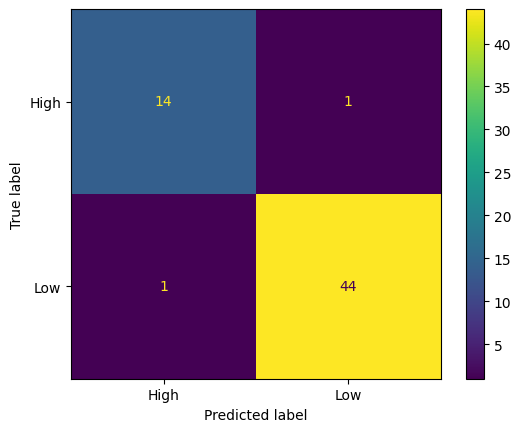

In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')

labels = ["High", "Low"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()